# Problem Statement 

**This dataset provides a comprehensive collection of information on various laptops, 
enabling a detailed analysis of their specifications and pricing. 
It encompasses a wide range of laptops, encompassing diverse brands, models, and 
configurations, making it a valuable resource for researchers, data analysts, and 
machine learning enthusiasts interested in the laptop industry.**

**The data comes from the spanish website PC componentes.**

**Fields included:**

* Laptop Name: The unique identifier or model name of the laptop.
* Brand: Laptop brand.
* Model: Laptop brand model.
* CPU (Central Processing Unit): The processor brand, model, and other relevant details.
* GPU (Graphics Processing Unit): The graphics card brand, model, and associated specifications.
* RAM (Random Access Memory): The amount of memory available for multitasking.
* Storage: The storage type (HDD, SSD) and capacity of the laptop.
* Price: The cost of the laptop in the respective currency.

**By utilizing this dataset, researchers and analysts can explore patterns, trends, and relationships between laptop specifications and their pricing. It serves as an excellent resource for tasks such as price prediction, market analysis, and comparison of different laptop configurations. Whether you are interested in identifying the most cost-effective options or understanding the impact of specific hardware components on laptop prices, this dataset offers abundant possibilities for in-depth exploration.**

## Neccessary Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt 
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

## DataSet

In [2]:
df=pd.read_csv("laptops.csv")
df

,Laptop,Status,Brand,Model,CPU,RAM,Storage,Storage type,GPU,Screen,Touch,Final Price
0,ASUS ExpertBook B1 B1502CBA-EJ0436X Intel Core...,New,Asus,ExpertBook,Intel Core i5,8,512,SSD,NaN,15.6,No,1009.00
1,Alurin Go Start Intel Celeron N4020/8GB/256GB ...,New,Alurin,Go,Intel Celeron,8,256,SSD,NaN,15.6,No,299.00
2,ASUS ExpertBook B1 B1502CBA-EJ0424X Intel Core...,New,Asus,ExpertBook,Intel Core i3,8,256,SSD,NaN,15.6,No,789.00
3,MSI Katana GF66 12UC-082XES Intel Core i7-1270...,New,MSI,Katana,Intel Core i7,16,1000,SSD,RTX 3050,15.6,No,1199.00
4,HP 15S-FQ5085NS Intel Core i5-1235U/16GB/512GB...,New,HP,15S,Intel Core i5,16,512,SSD,NaN,15.6,No,669.01
...,...,...,...,...,...,...,...,...,...,...,...,...
2155,Razer Blade 17 FHD 360Hz Intel Core i7-11800H/...,Refurbished,Razer,Blade,Intel Core i7,16,1000,SSD,RTX 3060,17.3,No,2699.99
2156,Razer Blade 17 FHD 360Hz Intel Core i7-11800H/...,Refurbished,Razer,Blade,Intel Core i7,16,1000,SSD,RTX 3070,17.3,No,2899.99
2157,Razer Blade 17 FHD 360Hz Intel Core i7-11800H/...,Refurbished,Razer,Blade,Intel Core i7,32,1000,SSD,RTX 3080,17.3,No,3399.99
2158,Razer Book 13 Intel Evo Core i7-1165G7/16GB/1T...,Refurbished,Razer,Book,Intel Evo Core i7,16,1000,SSD,NaN,13.4,Yes,1899.99


## 1.Basic Analysis 

In [3]:
df.shape

(2160, 12)

#### 1.1 No.of Rows : 2160
#### 1.2 No.of Columns : 12

#### 1.3 DataType of Each Feature

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2160 entries, 0 to 2159
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Laptop        2160 non-null   object 
 1   Status        2160 non-null   object 
 2   Brand         2160 non-null   object 
 3   Model         2160 non-null   object 
 4   CPU           2160 non-null   object 
 5   RAM           2160 non-null   int64  
 6   Storage       2160 non-null   int64  
 7   Storage type  2118 non-null   object 
 8   GPU           789 non-null    object 
 9   Screen        2156 non-null   float64
 10  Touch         2160 non-null   object 
 11  Final Price   2160 non-null   float64
dtypes: float64(2), int64(2), object(8)
memory usage: 202.6+ KB


#### 1.4 Basic Statistics of Numeric Columns 

In [5]:
df.describe()

,RAM,Storage,Screen,Final Price
count,2160.000000,2160.000000,2156.000000,2160.000000
mean,15.413889,596.294444,15.168112,1312.638509
std,9.867815,361.220506,1.203329,911.475417
min,4.000000,0.000000,10.100000,201.050000
25%,8.000000,256.000000,14.000000,661.082500
50%,16.000000,512.000000,15.600000,1031.945000
75%,16.000000,1000.000000,15.600000,1708.970000
max,128.000000,4000.000000,18.000000,7150.470000


#### 1.5 Basic Analysis of Category Column

In [6]:
df.describe(include='O')

,Laptop,Status,Brand,Model,CPU,Storage type,GPU,Touch
count,2160,2160,2160,2160,2160,2118,789,2160
unique,2160,2,27,121,28,2,44,2
top,ASUS ExpertBook B1 B1502CBA-EJ0436X Intel Core...,New,Asus,15S,Intel Core i7,SSD,RTX 3050,No
freq,1,1498,415,115,710,2062,129,1933


#### 1.6 Numeric Feature

In [7]:
Numeric_cols=df.select_dtypes(include=np.number).columns.tolist()
Numeric_cols

['RAM', 'Storage', 'Screen', 'Final Price']

#### 1.7 Category Feature

In [8]:
Category_cols=df.select_dtypes(include='O').columns.tolist()
Category_cols

['Laptop', 'Status', 'Brand', 'Model', 'CPU', 'Storage type', 'GPU', 'Touch']

## Basic Analysis Report 

* Rows : 2160 and Columns : 12
* Numeric Feature : 4 and Category Feature : 8

## 2.Exploratory Data Analysis

#### 2.1 Univariate Analysis

#### Numeric Feature 

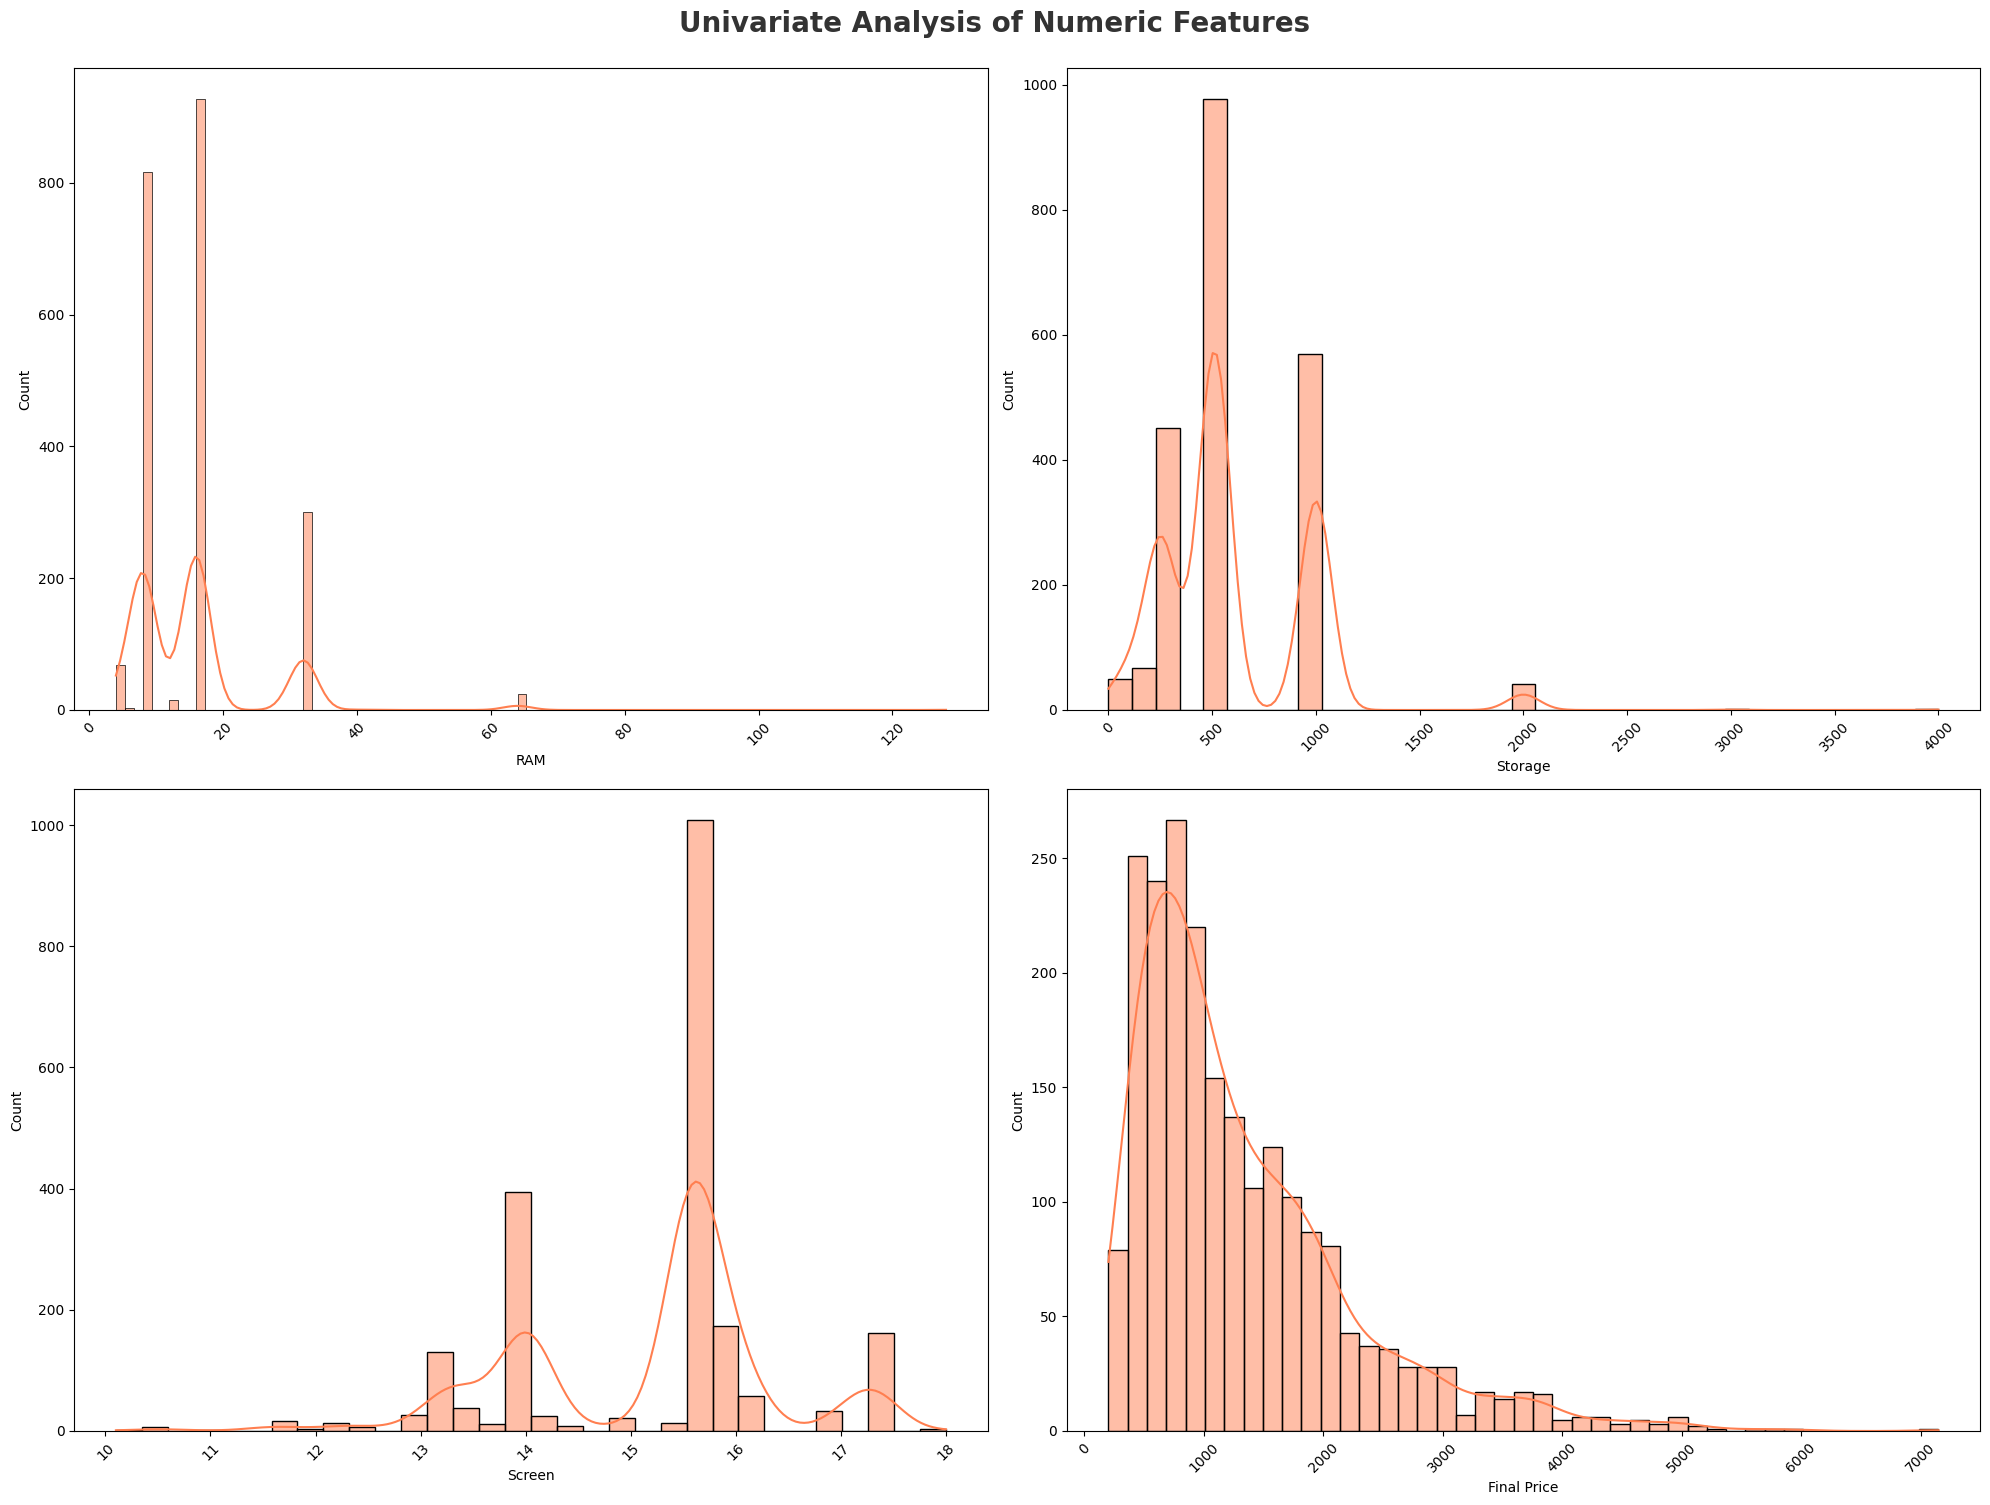

In [9]:
plt.figure(figsize=(20, 15))
plt.suptitle('Univariate Analysis of Numeric Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)
for i in range(0, len(Numeric_cols)):
    plt.subplot(2, 2, i+1)
    sns.histplot(x=df[Numeric_cols[i]],kde=True,color='coral')
    plt.xlabel(Numeric_cols[i])
    plt.xticks(rotation=45)
    plt.tight_layout()

**Analysis :**

* Final Price is Right Skewed 

#### Category Feature 

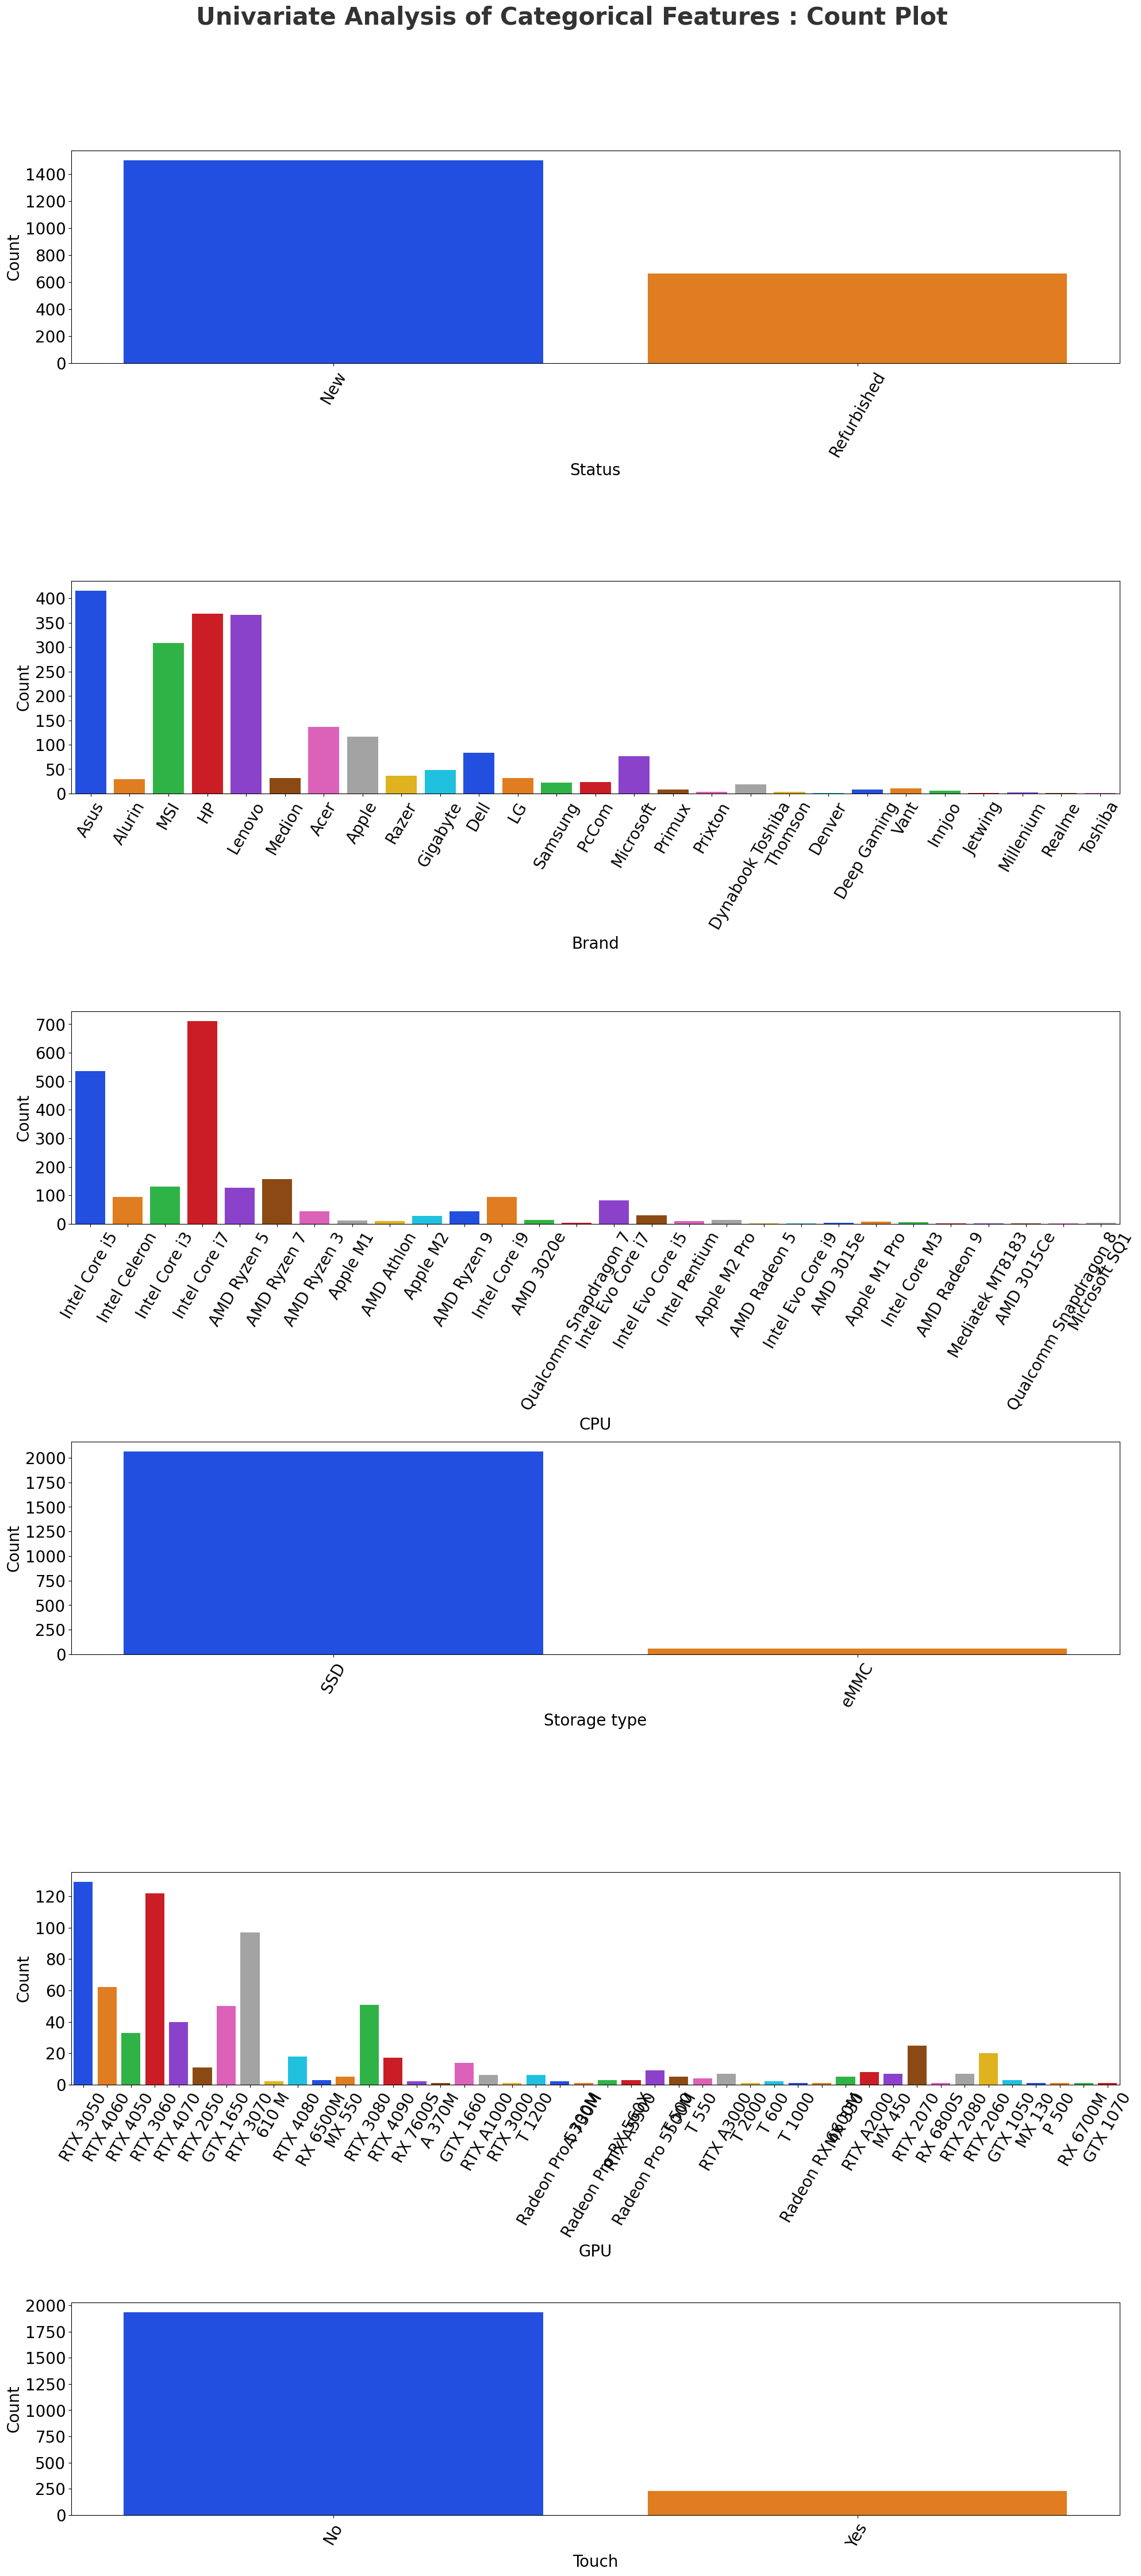

In [10]:
import math
n_cols = 1
n_rows = math.ceil(len(Category_cols) / n_cols)

plt.figure(figsize=(20, 60))
plt.suptitle('Univariate Analysis of Categorical Features : Count Plot',fontsize=30,
    fontweight='bold',
    alpha=0.8
)
temp=['Status', 'Brand','CPU', 'Storage type', 'GPU', 'Touch']

for i, col in enumerate(temp):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(data=df, x=col, palette='bright')
    plt.xlabel(col)
    plt.xticks(rotation=45)

    plt.xlabel(col, fontsize=20)
    plt.ylabel('Count', fontsize=20)

   
    plt.xticks(rotation=60, fontsize=20)
    plt.yticks(fontsize=20)


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


**Analysis**

* Most Of Laptop are New
* Most Prefered Brands : Asus,MSI,HP,Lenvo
* Most Prefered CPU : inter core i7,intel core i5
* Most Prefered GPU : RTX 3050,4050,1650
* Most prefer SSD storage and Without Touch Screen

#### 2.2 Bivariate Analysis

#### Numeric vs Numeric Feature 

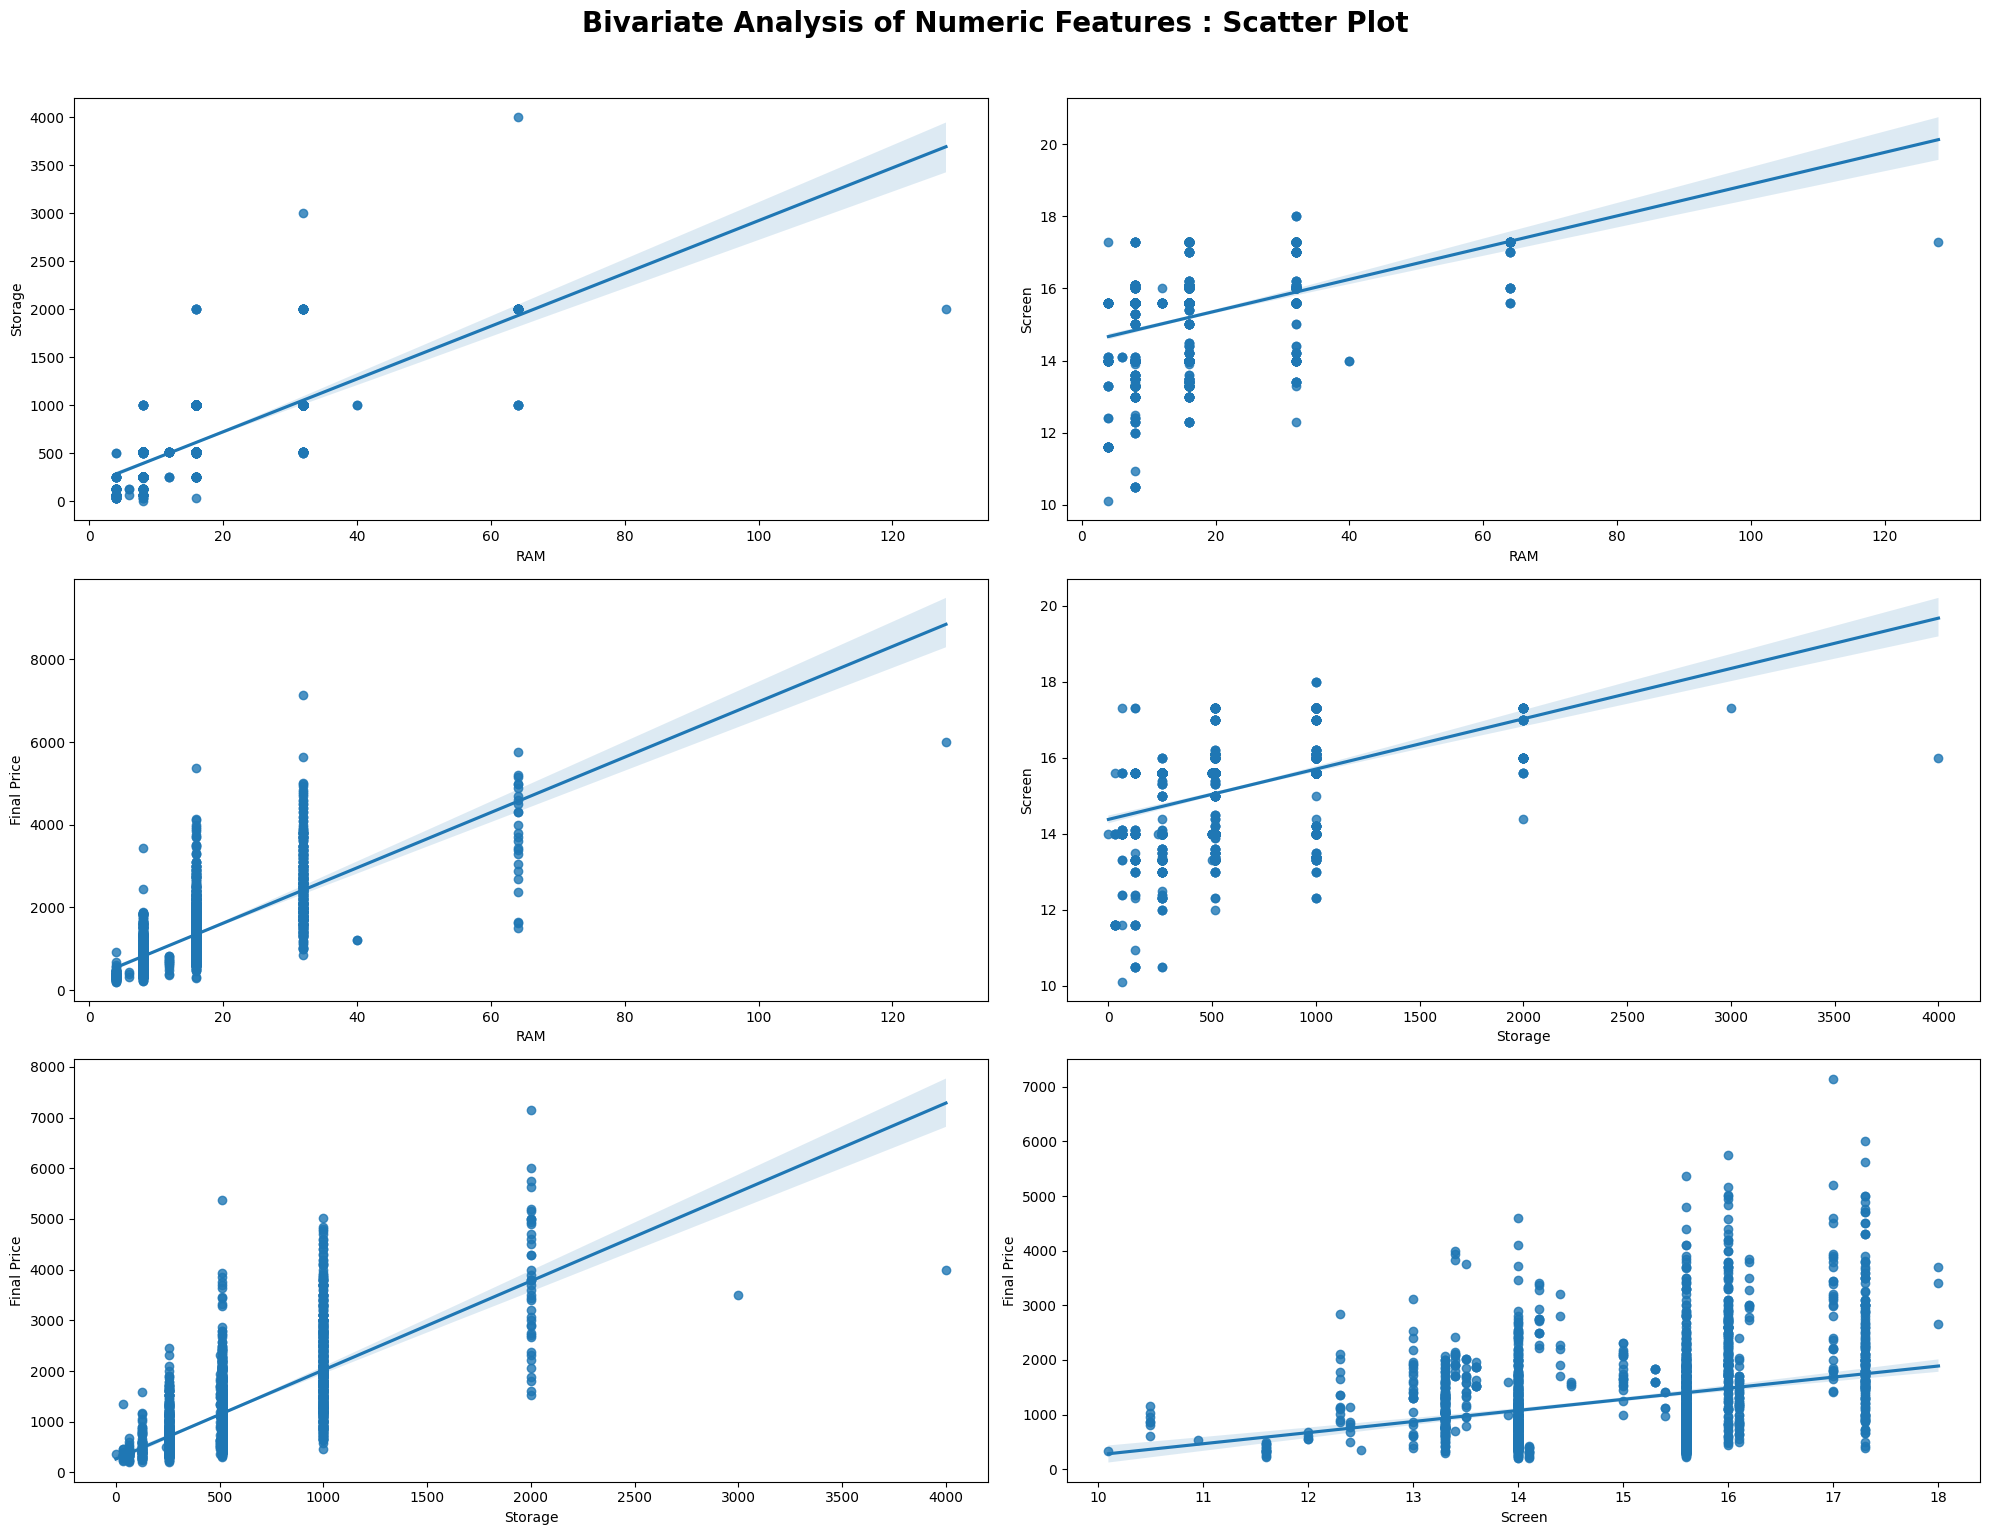

In [11]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

pairs = [(Numeric_cols[i], Numeric_cols[j])
         for i in range(len(Numeric_cols))
         for j in range(i+1, len(Numeric_cols))]

n_plots = len(pairs)
n_cols = 2
n_rows = math.ceil(n_plots / n_cols)

plt.figure(figsize=(20, 5 * n_rows))
plt.suptitle(
    "Bivariate Analysis of Numeric Features : Scatter Plot",
    fontsize=20, fontweight='bold', y=1.02
)

for idx, (x, y) in enumerate(pairs):
    plt.subplot(n_rows, n_cols, idx + 1)
    sns.regplot(x=df[x], y=df[y],)
    plt.xlabel(x)
    plt.ylabel(y)

plt.tight_layout()
plt.show()


**Analysis**

**Realtionship Traget Vaible (Final Price)**

* Storage and Ram are Highly positively correalted ie highly influnece price
* Screen is less positively correalted

**For Other features also there is Linear Relationship**

#### Correaltion

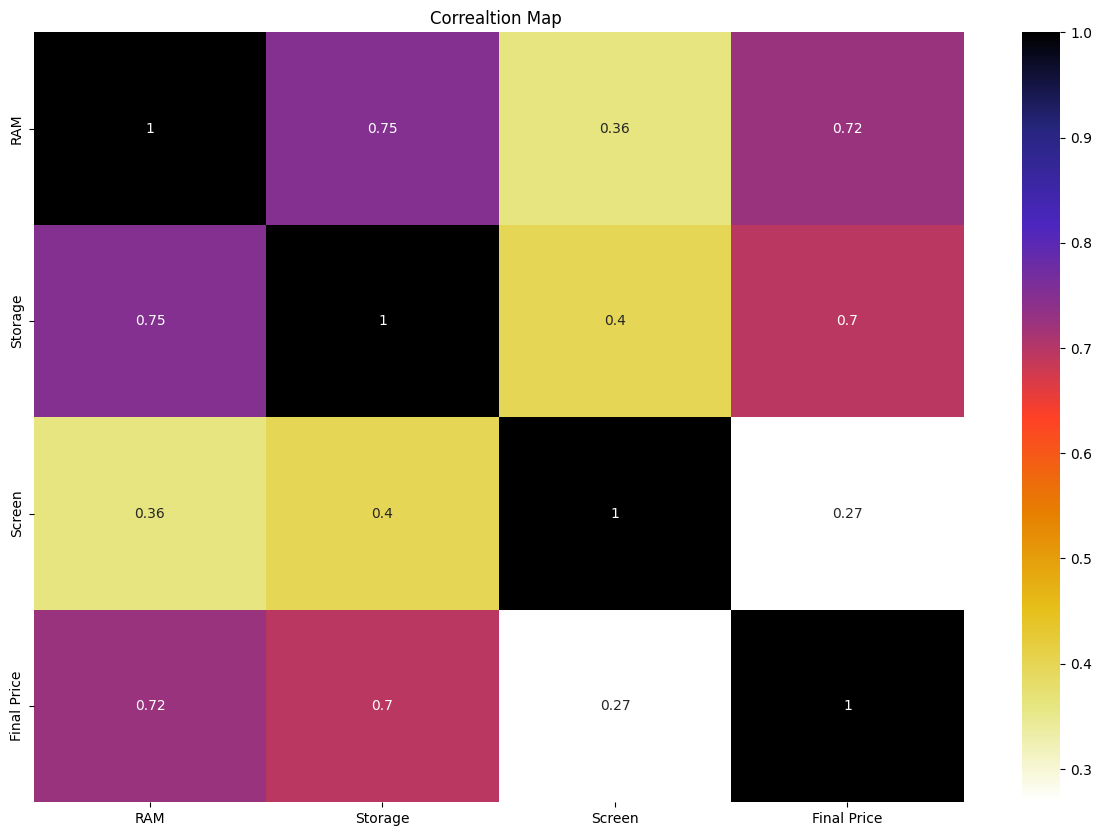

In [12]:
plt.figure(figsize = (15,10))
plt.title("Correaltion Map ")
sns.heatmap(df.corr(numeric_only=True), cmap="CMRmap_r", annot=True)
plt.show()

**Analysis**

* Final Price and Ram are highly Positive Correalted


#### Category vs Category 

In [13]:
for i in Category_cols:
    print("No of Unique Values  ",i," : ",df[i].nunique())

No of Unique Values   Laptop  :  2160
No of Unique Values   Status  :  2
No of Unique Values   Brand  :  27
No of Unique Values   Model  :  121
No of Unique Values   CPU  :  28
No of Unique Values   Storage type  :  2
No of Unique Values   GPU  :  44
No of Unique Values   Touch  :  2


In [14]:
def FrequencyTable(df,cols1,cols2):
        print("Frequency Distribution of ",cols1," With ",cols2)
        print("==================================================================")
        print(pd.crosstab(df[cols1],columns=df[cols2],dropna=True))
        print("===================================================================")


In [15]:
grp=df.groupby("Brand").count()
grp

,Laptop,Status,Model,CPU,RAM,Storage,Storage type,GPU,Screen,Touch,Final Price
Brand,,,,,,,,,,,
Acer,137,137,137,137,137,137,137,51,136,137,137
Alurin,29,29,29,29,29,29,25,0,29,29,29
Apple,116,116,116,116,116,116,105,9,116,116,116
Asus,415,415,415,415,415,415,409,168,415,415,415
Deep Gaming,8,8,8,8,8,8,8,8,8,8,8
Dell,84,84,84,84,84,84,84,6,84,84,84
Denver,1,1,1,1,1,1,1,0,1,1,1
Dynabook Toshiba,19,19,19,19,19,19,19,0,19,19,19
Gigabyte,48,48,48,48,48,48,48,46,48,48,48


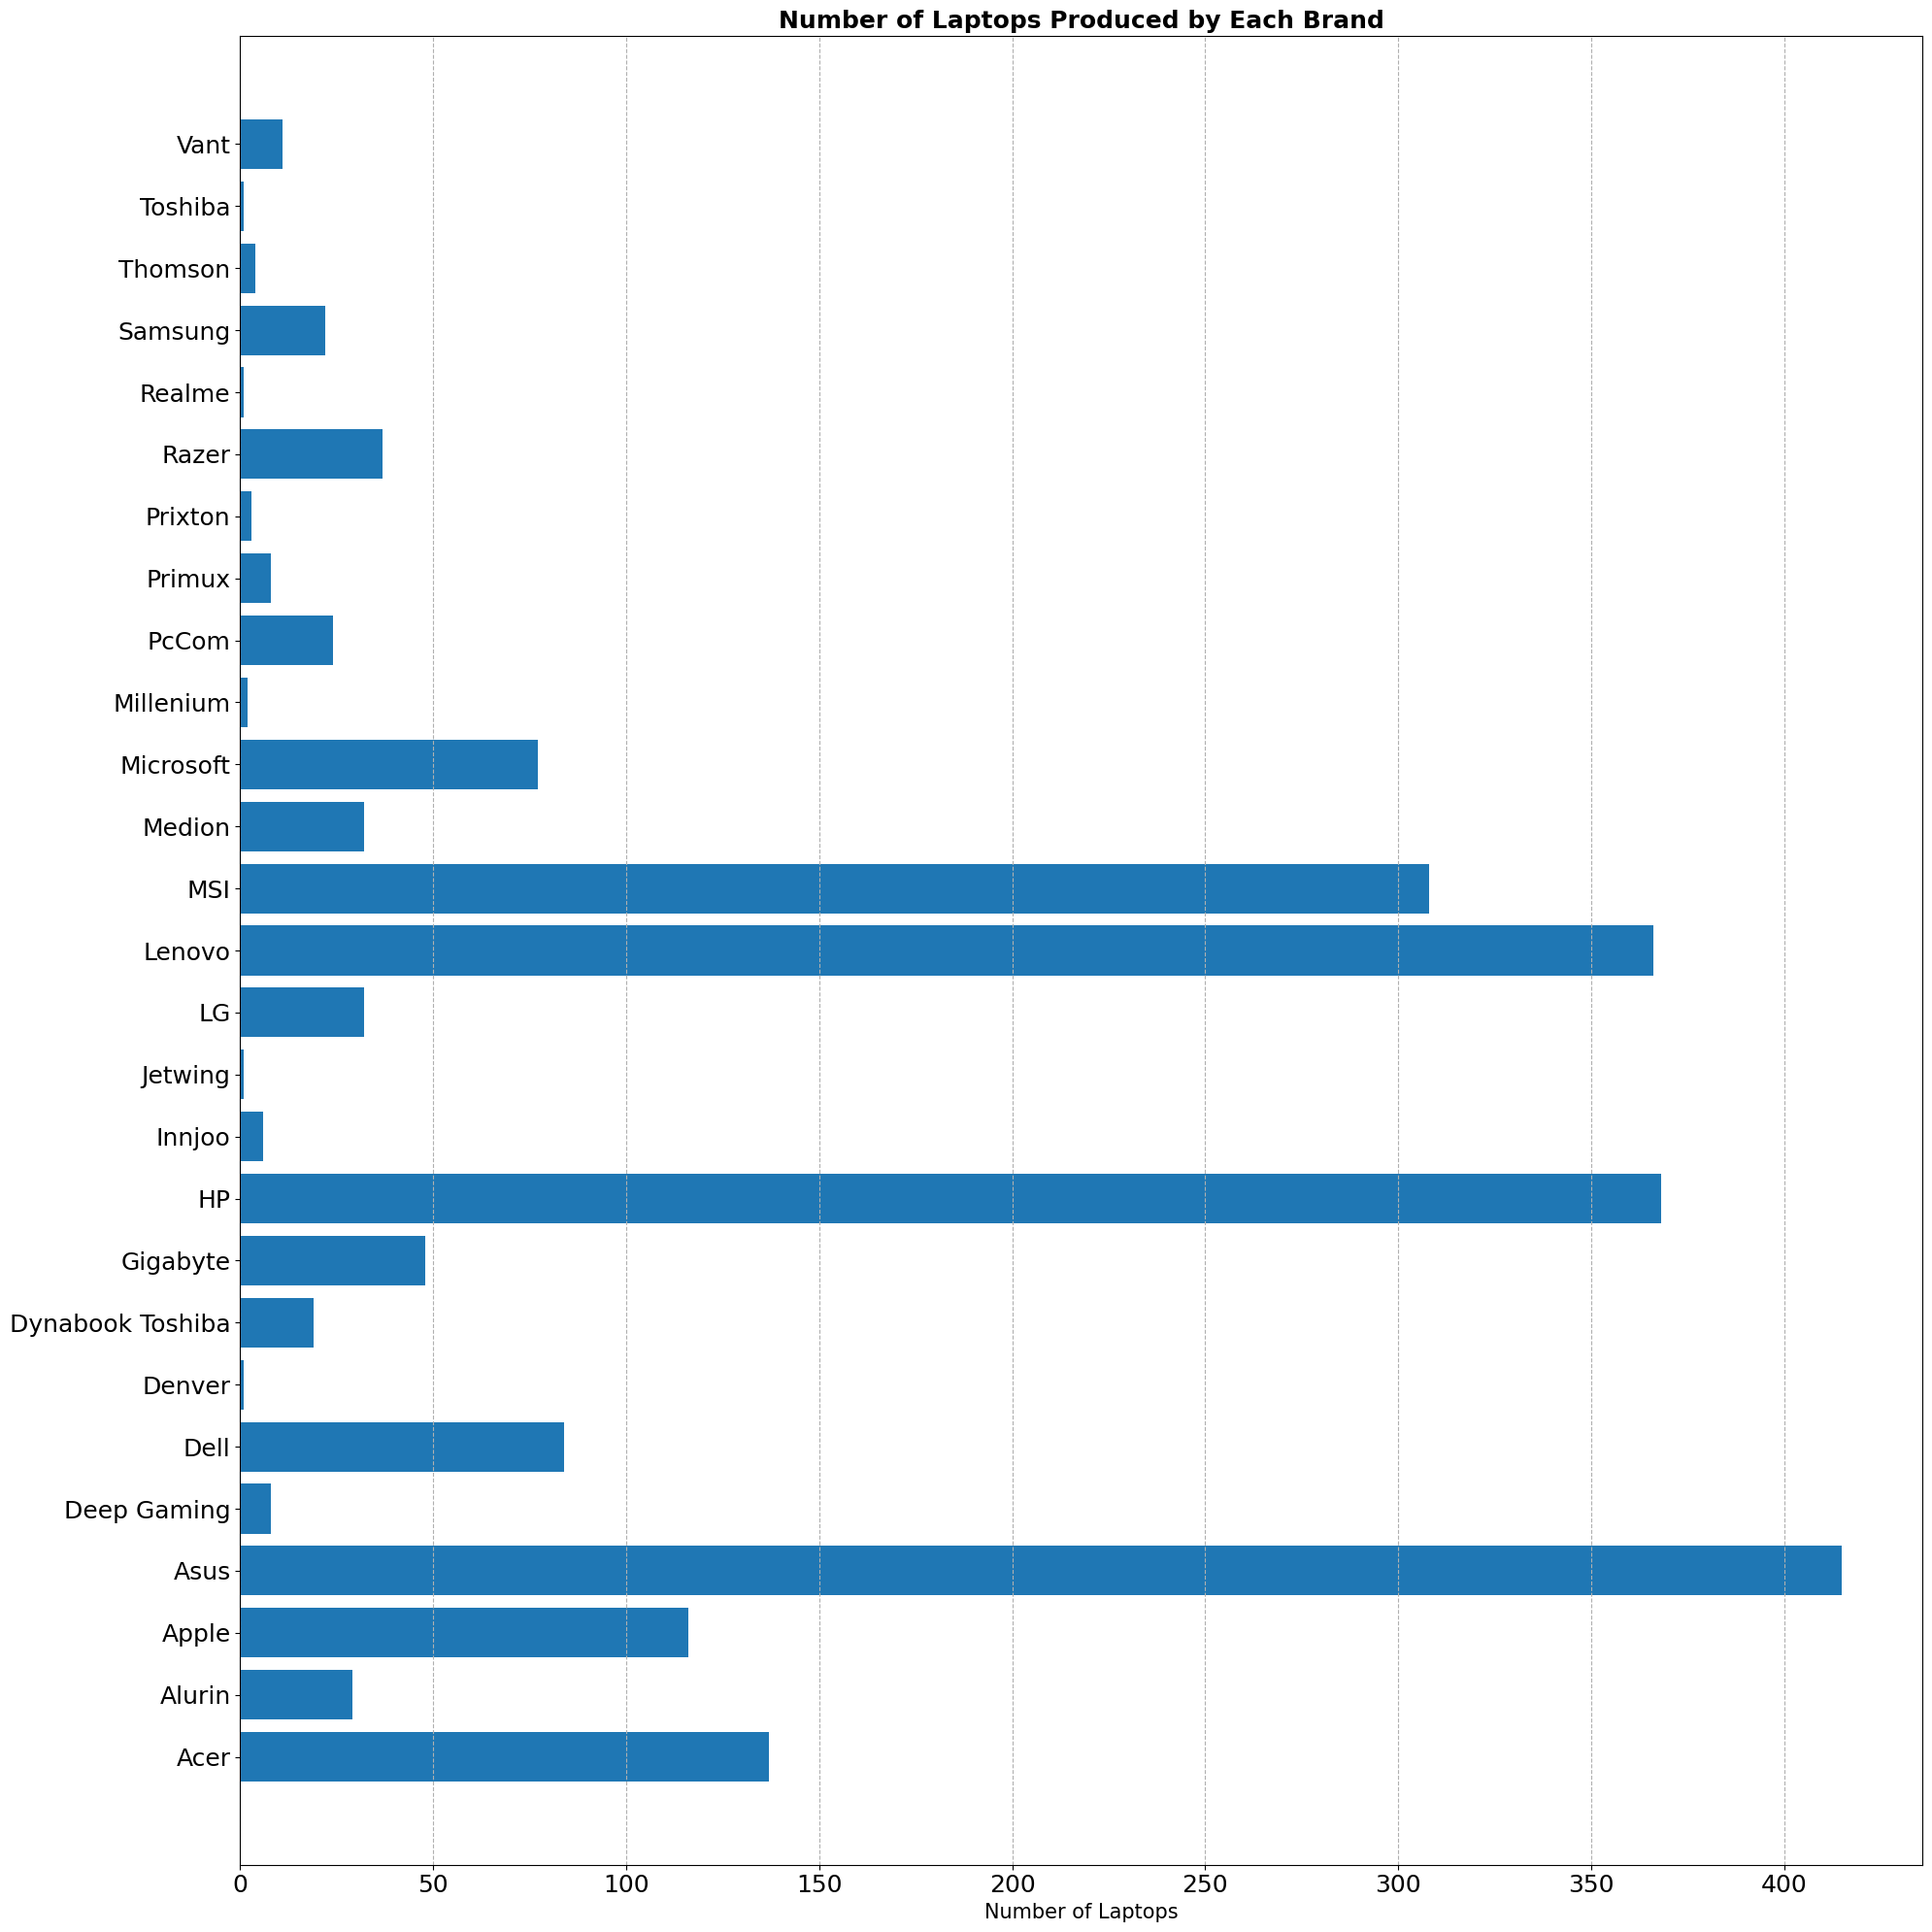

In [16]:
plt.figure(figsize=(20, 20))
plt.barh(grp.index, grp["Laptop"])
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel("Number of Laptops", fontsize=15)
plt.title("Number of Laptops Produced by Each Brand", fontsize=18, fontweight='bold')
plt.grid(axis='x', linestyle='--',visible=True)
plt.tight_layout()
plt.show()


## 3.Feature Engineering 

### 3.1 Handling Missing Value 

**Missing Value in Each Feature**

In [17]:
df.isnull().sum()

Laptop             0
Status             0
Brand              0
Model              0
CPU                0
RAM                0
Storage            0
Storage type      42
GPU             1371
Screen             4
Touch              0
Final Price        0
dtype: int64

**Storage type,GPU and Screen has Null values**

In [18]:
df['Storage type']=df['Storage type'].fillna("Others")

In [19]:
df['Storage type'].value_counts()

Storage type
SSD       2062
eMMC        56
Others      42
Name: count, dtype: int64

In [20]:
print(df['Screen'].std())
print((df['Screen'].fillna(df['Screen'].median())).std())

1.2033287583284522
1.2023569841812647


In [21]:
df['Screen']=df['Screen'].fillna(df['Screen'].median()) 

In [22]:
df['Screen'].isnull().sum()

np.int64(0)

In [23]:
df['GPU']=df['GPU'].fillna("Others")

In [24]:
df['GPU'].value_counts()

GPU
Others                1371
RTX 3050               129
RTX 3060               122
RTX 3070                97
RTX 4060                62
RTX 3080                51
GTX 1650                50
RTX 4070                40
RTX 4050                33
RTX 2070                25
RTX 2060                20
RTX 4080                18
RTX 4090                17
GTX 1660                14
RTX 2050                11
Radeon Pro 5500M         9
RTX A2000                8
MX 450                   7
RTX 2080                 7
RTX A3000                7
T 1200                   6
RTX A1000                6
MX 330                   5
MX 550                   5
T 500                    5
T 550                    4
RX 6500M                 3
GTX 1050                 3
Radeon Pro RX 560X       3
RTX A5500                3
610 M                    2
RX 7600S                 2
Radeon Pro 5300M         2
T 600                    2
A 730M                   1
A 370M                   1
RTX 3000                

**Work Done** 
* Storage Type,Gpu and Screen Has NaN values
* Storage Type substitued with other beacuse there can be any other types of storage also
* GPU substitued with other because there is lots of Gpu be available
* Screen substitued with median, only 4 missing .Not much Impact  


### 3.2 Handling Duplicate Values 

In [25]:
df.duplicated().sum()

np.int64(0)

**Analysis**
* No Duplicated Record Present

### 3.3 Handling Outliers

In [26]:
df['RAM'].unique()

array([  8,  16,  32,  12,   4,  64, 128,   6,  40])

In [27]:
df['Storage'].unique()

array([ 512,  256, 1000,   64,  128,   32,    0, 2000,  500, 4000, 3000,
        240])

In [28]:
df['Screen'].unique()

array([15.6 , 17.3 , 14.  , 16.1 , 13.3 , 16.  , 13.6 , 17.  , 15.3 ,
       14.5 , 13.4 , 14.2 , 18.  , 14.1 , 12.4 , 13.5 , 16.2 , 15.  ,
       11.6 , 13.  , 10.5 , 14.4 , 12.3 , 15.4 , 12.5 , 10.1 , 10.95,
       12.  , 13.9 ])

**Analysis**
* There is No outlier because all this value are correct .
* There is Ram with size 128,64,...
* There is Storage with size 3000,1000,...
* There is Screen with size 17.3,16.0,...
* So all this are valid value . so There is No Outlier
* Only replace storage with size=0 ,with median because storage cannot be zero 

In [29]:
df['Storage'] = df['Storage'].replace(0, np.nan)
df['Storage'].fillna(df['Storage'].median(), inplace=True)

In [30]:
df['Storage'].unique()

array([ 512.,  256., 1000.,   64.,  128.,   32., 2000.,  500., 4000.,
       3000.,  240.])

### 3.4 Removing Unnecessary Columns/Features

In [31]:
Category_cols

['Laptop', 'Status', 'Brand', 'Model', 'CPU', 'Storage type', 'GPU', 'Touch']

In [32]:
for i in Category_cols:
    print(i," No of Unique Values : ",df[i].nunique()) 

Laptop  No of Unique Values :  2160
Status  No of Unique Values :  2
Brand  No of Unique Values :  27
Model  No of Unique Values :  121
CPU  No of Unique Values :  28
Storage type  No of Unique Values :  3
GPU  No of Unique Values :  45
Touch  No of Unique Values :  2


In [33]:
df['Laptop'].unique()

array(['ASUS ExpertBook B1 B1502CBA-EJ0436X Intel Core i5-1235U/8GB/512GB SSD/15.6"',
       'Alurin Go Start Intel Celeron N4020/8GB/256GB SSD/15.6"',
       'ASUS ExpertBook B1 B1502CBA-EJ0424X Intel Core i3-1215U/8GB/256GB SSD/15.6"',
       ...,
       'Razer Blade 17 FHD 360Hz Intel Core i7-11800H/32GB/1TB SSD/RTX 3080/17.3"',
       'Razer Book 13 Intel Evo Core i7-1165G7/16GB/1TB SSD/13.4" Táctil',
       'Razer Book FHD+ Intel Evo Core i7-1165G7/16GB/256GB SSD/13.4" Táctil'],
      shape=(2160,), dtype=object)

**Analysis**

* Laptop Feature contains all the details like Model,brand,ssd,storage size,....
* This is NOT a feature — it’s raw text metadata
* Laptop Feature is Droped 

In [34]:
df.drop(columns=['Laptop'], inplace=True)

In [35]:
Category_cols.remove('Laptop')

In [36]:
Category_cols

['Status', 'Brand', 'Model', 'CPU', 'Storage type', 'GPU', 'Touch']

### 3.5 Transformation

* Apply Transformation if there is skewness ie (Right ot Left skew)
* Ram,Storage,Screen there is skewness but that is okay beacause it was unique value
* Final Price is Right Skew so Requires some Transformation 

In [37]:
import scipy.stats as stat
import pylab 
def plot_data(df,feature):
    plt.figure(figsize=(10,6))
    plt.subplot(1,2,1)
    df[feature].hist()
    plt.subplot(1,2,2)
    stat.probplot(df[feature],dist='norm',plot=pylab)
    plt.show()

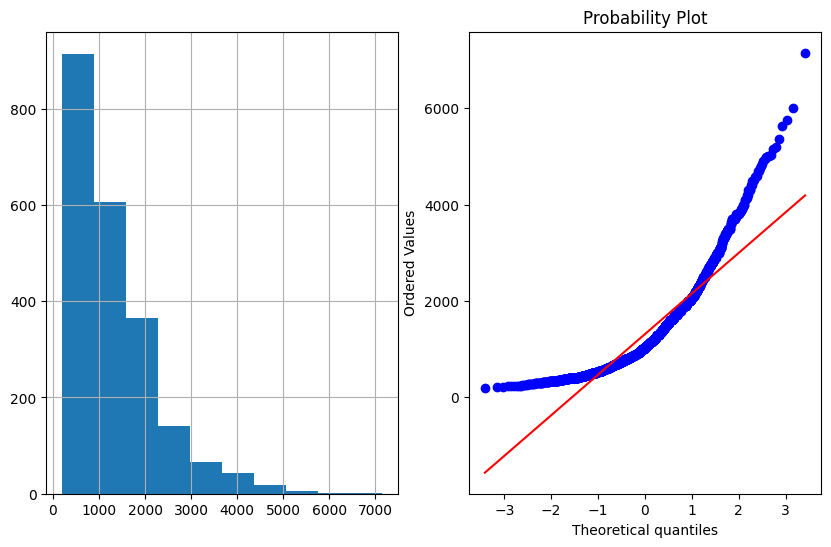

In [38]:
plot_data(df,'Final Price')

**Log Transformation**

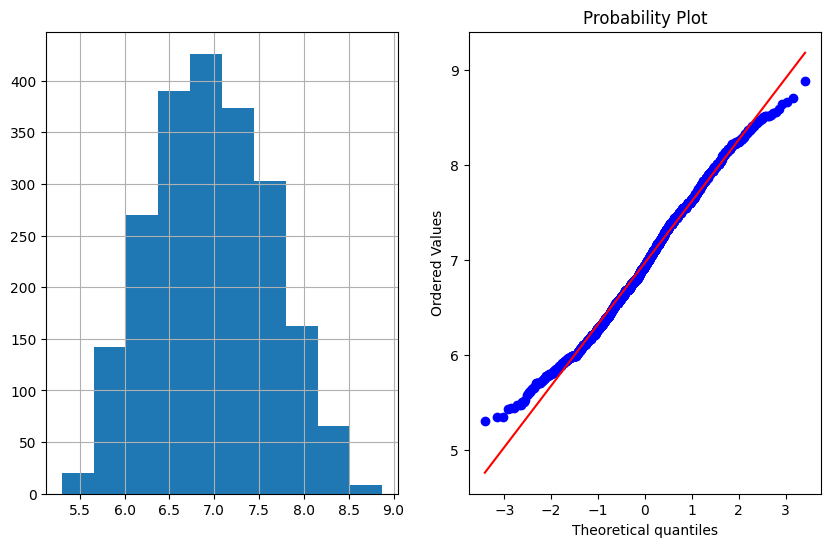

In [39]:
df['Final Price']=np.log(df['Final Price'])
plot_data(df,'Final Price')

### 3.6 Split Data Into Train and Test 

In [40]:
from sklearn.model_selection import train_test_split
X = df.drop('Final Price', axis=1)
y = df['Final Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Analysis**

* Data is Splitted into Dependent and Independent Feature
* Data is Splitted into Train and Test. Test size=0.2 ie contains 20% of original data

### 3.7 Handling Categorical Data 

In [41]:
from category_encoders import TargetEncoder

cat_cols = ['Brand','Model','CPU','GPU','Storage type','Touch','Status']

te = TargetEncoder(cols=cat_cols)

X_train[cat_cols] = te.fit_transform(X_train[cat_cols], y_train)
X_test[cat_cols] = te.transform(X_test[cat_cols])

**Analysis**
* Applied Traget Encoding in category cols of Train data

### 3.8 Standardization 

* Actually All model doesn't requires standardization like Adaboost,CatBoost,..
* Where as Some model requires standardization so that model accurracy will increases
* So we create two thing standarized data and unstandarized data

**Standard Data**

In [42]:
from sklearn.preprocessing import StandardScaler
num_cols = ['RAM','Storage','Screen']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

**Normal Data Without standard**

In [43]:
X_train_unscaled = X_train.copy()
X_test_unscaled = X_test.copy()

## 4.Model Training 

* **Here should understand the Various Regression models with default values from these models we can choose top 4 with Highest Accuracy score 
and proceed with HyperParameter Tuning**

**Import Required packages for model training**

In [44]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

**Create a Function to Evaluate Model**

In [45]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

**Model With Default Parameter Value**

In [46]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "KNN Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "AdaBoost Regressor": AdaBoostRegressor(random_state=42),
    "CatBoost Regressor": CatBoostRegressor(verbose=False, random_state=42),
    "XGBRegressor": XGBRegressor(random_state=42)
}

**Scaled Model**

In [47]:
scaled_models = [
    "Linear Regression",
    "Lasso",
    "Ridge",
    "KNN Regressor",
    "SVR"
]

In [48]:
model_list = []
r2_list = []

for name, model in models.items():
    
    
    if name in scaled_models:
        model.fit(X_train_scaled, y_train)
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

    
    train_mae, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
    test_mae, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)

    model_list.append(name)
    r2_list.append(test_r2)

    print(name)
    print("Model performance for Training set")
    print(f"- RMSE: {train_rmse:.4f}")
    print(f"- MAE : {train_mae:.4f}")
    print(f"- R2  : {train_r2:.4f}")

    print("----------------------------------")

    print("Model performance for Test set")
    print(f"- RMSE: {test_rmse:.4f}")
    print(f"- MAE : {test_mae:.4f}")
    print(f"- R2  : {test_r2:.4f}")

    print("="*40, "\n")


Linear Regression
Model performance for Training set
- RMSE: 0.2919
- MAE : 0.2265
- R2  : 0.7951
----------------------------------
Model performance for Test set
- RMSE: 0.3078
- MAE : 0.2350
- R2  : 0.7830

Lasso
Model performance for Training set
- RMSE: 0.6448
- MAE : 0.5352
- R2  : 0.0000
----------------------------------
Model performance for Test set
- RMSE: 0.6630
- MAE : 0.5416
- R2  : -0.0065

Ridge
Model performance for Training set
- RMSE: 0.3027
- MAE : 0.2350
- R2  : 0.7796
----------------------------------
Model performance for Test set
- RMSE: 0.3164
- MAE : 0.2439
- R2  : 0.7708

KNN Regressor
Model performance for Training set
- RMSE: 0.2366
- MAE : 0.1780
- R2  : 0.8653
----------------------------------
Model performance for Test set
- RMSE: 0.2982
- MAE : 0.2226
- R2  : 0.7963

Decision Tree
Model performance for Training set
- RMSE: 0.1063
- MAE : 0.0541
- R2  : 0.9728
----------------------------------
Model performance for Test set
- RMSE: 0.3256
- MAE : 0.22

**Results of All Models**

In [49]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
7,CatBoost Regressor,0.883921
8,XGBRegressor,0.872556
5,Random Forest,0.853902
3,KNN Regressor,0.796321
0,Linear Regression,0.782984
6,AdaBoost Regressor,0.779699
2,Ridge,0.770752
4,Decision Tree,0.757217
1,Lasso,-0.006464


**Report**
* CatBoost,XGBregressor,Random Forest,KNN Regressor perform well
* Which can be Hyperparameter tuning

### 4.2 HyperParameter tuning

**KNN HyperTuning**

In [50]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor()

knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # Manhattan vs Euclidean
}

knn_search = RandomizedSearchCV(
    knn_model,
    param_distributions=knn_params,
    n_iter=15,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

knn_search.fit(X_train_scaled, y_train)

print("Best KNN params:", knn_search.best_params_)
print("Best CV R2:", knn_search.best_score_)


Best KNN params: {'weights': 'distance', 'p': 1, 'n_neighbors': 7}
Best CV R2: 0.8111855561587734


**Random Forest HyperTuning**

In [51]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_params = {
    'n_estimators': [200, 400, 600],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    rf_model,
    param_distributions=rf_params,
    n_iter=20,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)

print("Best RF params:", rf_search.best_params_)
print("Best CV R2:", rf_search.best_score_)


Best RF params: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Best CV R2: 0.8647541505006487


**XGBregressor HyperTuning**

In [52]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

xgb_params = {
    'n_estimators': [300, 500, 800],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=xgb_params,
    n_iter=20,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

print("Best XGB params:", xgb_search.best_params_)
print("Best CV R2:", xgb_search.best_score_)


Best XGB params: {'subsample': 0.8, 'n_estimators': 800, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best CV R2: 0.8761863641256288


**CatBoost Regressor HyperTuning**

In [53]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    loss_function='RMSE',
    random_state=42,
    verbose=False
)

cat_params = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'iterations': [300, 500, 800],
    'l2_leaf_reg': [1, 3, 5, 7, 9]
}

cat_search = RandomizedSearchCV(
    cat_model,
    param_distributions=cat_params,
    n_iter=20,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

cat_search.fit(X_train, y_train)

print("Best CatBoost params:", cat_search.best_params_)
print("Best CV R2:", cat_search.best_score_)


Best CatBoost params: {'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 500, 'depth': 6}
Best CV R2: 0.8733878406050278


**Applying Model With the best parameter to test data**

In [54]:
final_models = {
    "XGBoost": xgb_search.best_estimator_,
    "CatBoost": cat_search.best_estimator_,
    "RandomForest": rf_search.best_estimator_,
    "KNN": knn_search.best_estimator_
}

for name, model in final_models.items():
    if name == "KNN":
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    mae, rmse, r2 = evaluate_model(y_test, y_pred)
    print(f"{name} → RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")


XGBoost → RMSE: 0.2217, MAE: 0.1559, R2: 0.8875
CatBoost → RMSE: 0.2270, MAE: 0.1649, R2: 0.8820
RandomForest → RMSE: 0.2420, MAE: 0.1681, R2: 0.8659
KNN → RMSE: 0.2872, MAE: 0.2031, R2: 0.8111


**Final Model**
* XGBRegressor is The Best Model because it has Lowest RMSE,Lowest MAE,Highest R²,Stable gap between 
train & test

In [68]:
final_model= xgb_search.best_estimator_
y_test_pred = final_model.predict(X_test)

**Resdiual Plot**

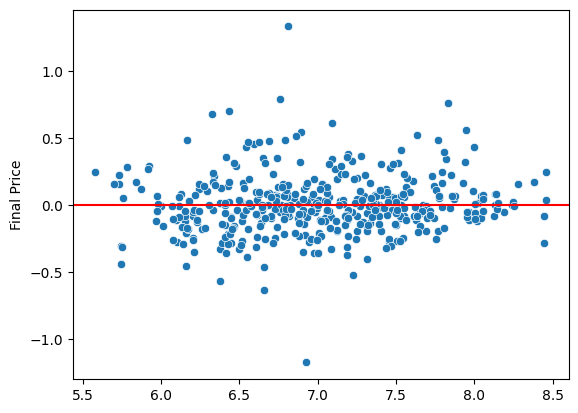

In [64]:
residuals = y_test - y_test_pred
sns.scatterplot(x=y_test_pred, y=residuals)
plt.axhline(0, color='red')
plt.show()

**Analysis**

* Points are evenly scattered above and below the red zero line which indicates No clear curve, funnel shape, or pattern.It means your model has captured the main relationship correctly.
* Mean of residuals ≈ 0 , implies Model is unbiased
* No heteroscedasticity problem
* Few Ouliers,Not Much problem 

**Residual Distribution**

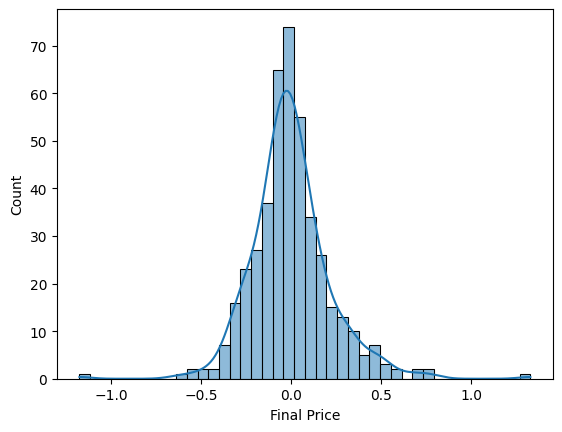

In [65]:
sns.histplot(residuals, kde=True)
plt.show()

**Analysis**

* Normal Distribution .

**Save The Model**

In [70]:
joblib.dump(final_model, "xgb_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(te, "encoder.pkl")

['encoder.pkl']

In [71]:
print(type(final_model))

<class 'xgboost.sklearn.XGBRegressor'>
